# Query Log Analysis — Vancouver Neighbourhood Safety Dashboard

## Why We chose Query Logging

The MongoDB query log captures every interaction a user has with the LLM-powered querychat interface. This data serves three core purposes:

1. **Understand user intent**: By analyzing the natural language queries, we learn what questions users actually have about Vancouver crime, not what we assumed they would ask. This directly informs future feature development and data collection priorities.

2. **Identify Desirous (High-Interest) Neighbourhoods**: By extracting neighbourhood mentions from queries and generated SQL, we can identify which areas users are most curious about and prioritize those in future dashboard enhancements.

3. **Identify data gaps**: When `n_rows = 0`, the query returned no results. Patterns in empty-result queries reveal gaps in our dataset or limitations in how the LLM translates questions to SQL.

4. **Improve the LLM prompt**: By reviewing `user_query` vs `sql` pairs, we can identify cases where the LLM misunderstood the user and refine the system prompt accordingly.



In [1]:
from dotenv import load_dotenv
from pymongo import MongoClient
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import plotly.express as px

import os

In [ ]:
load_dotenv(Path("../.env"))

client = MongoClient(os.getenv("MONGODB_URI"))
collection = client["van_safety_logs"]["query_log"]

# test connection
print(client.server_info())

{'version': '8.0.20', 'gitVersion': '28927c60881a488fcbc5fd4d925b410f33258827', 'modules': ['enterprise'], 'allocator': 'tcmalloc-google', 'javascriptEngine': 'mozjs', 'sysInfo': 'deprecated', 'versionArray': [8, 0, 20, 0], 'bits': 64, 'debug': False, 'maxBsonObjectSize': 16777216, 'storageEngines': ['devnull', 'inMemory', 'queryable_wt', 'wiredTiger'], 'ok': 1.0, '$clusterTime': {'clusterTime': Timestamp(1773766898, 34), 'signature': {'hash': b'\x1c\xcd\x00Aat\x86\x86\xf03\t-.\xba\x9b\xd81\x19#\x88', 'keyId': 7584201178540408837}}, 'operationTime': Timestamp(1773766898, 34)}


In [3]:
print("Current directory:", os.getcwd())

Current directory: /Users/braimah/Documents/MDS_UBS/Block5/532/DSCI-532_2026_7_vancouver-neighbourhood-safety/notebooks


In [4]:
SCHEMA = ["timestamp", "tool", "user_query", "llm_response", "sql", "n_rows"]


df = pd.DataFrame(list(collection.find({}, {"_id": 0})), columns=SCHEMA)

df["timestamp"] = pd.to_datetime(df["timestamp"])

In [5]:
df.head()

,timestamp,tool,user_query,llm_response,sql,n_rows
0,2026-03-16 09:43:15,querychat_query,"Hi, which city neigborhood the most crimes",NaN,"SELECT \n NEIGHBOURHOOD,\n COUNT(*) AS t...",32411
1,2026-03-16 09:44:49,querychat_query,Which crime is the most populous?,NaN,"SELECT \n TYPE AS crime_type,\n COUNT(*)...",32411
2,2026-03-16 09:58:35,querychat_query,"Hi, which neigbourhood has the largest crimes",NaN,"SELECT \n NEIGHBOURHOOD,\n COUNT(*) AS t...",32411
3,2026-03-16 10:08:51,querychat_query,,NaN,-- Compare Downtown crime rates to other neigh...,32411
4,2026-03-16 10:13:55,querychat_query,,NaN,WITH west_end_stats AS (\n SELECT COUNT(*) ...,32411


In [6]:
df

,timestamp,tool,user_query,llm_response,sql,n_rows
0,2026-03-16 09:43:15,querychat_query,"Hi, which city neigborhood the most crimes",NaN,"SELECT \n NEIGHBOURHOOD,\n COUNT(*) AS t...",32411
1,2026-03-16 09:44:49,querychat_query,Which crime is the most populous?,NaN,"SELECT \n TYPE AS crime_type,\n COUNT(*)...",32411
2,2026-03-16 09:58:35,querychat_query,"Hi, which neigbourhood has the largest crimes",NaN,"SELECT \n NEIGHBOURHOOD,\n COUNT(*) AS t...",32411
3,2026-03-16 10:08:51,querychat_query,,NaN,-- Compare Downtown crime rates to other neigh...,32411
4,2026-03-16 10:13:55,querychat_query,,NaN,WITH west_end_stats AS (\n SELECT COUNT(*) ...,32411
5,2026-03-16 10:16:38,querychat_query,"Hi, which month of the year has the most cromes",NaN,"SELECT \n MONTH_NAME,\n COUNT(*) AS crim...",32411
6,2026-03-16 10:18:19,querychat_query,Are there blocks with the most homicide crimes?,NaN,"SELECT \n HUNDRED_BLOCK,\n NEIGHBOURHOOD...",32411
7,2026-03-16 10:19:28,querychat_query,,NaN,"SELECT \n NEIGHBOURHOOD,\n COUNT(*) AS h...",32411
8,2026-03-16 10:23:27,querychat_query,What time of the day do most crimes occur?,NaN,"SELECT \n TIME_OF_DAY,\n COUNT(*) AS cri...",32411
9,2026-03-16 10:23:54,querychat_query,Show me crime patterns by hour of the day,NaN,"SELECT \n HOUR,\n COUNT(*) AS crime_coun...",32411


In [7]:
df.shape

(14, 6)

In [8]:
# Analysis of query frequency over time to identify peak usage hours
resampled = df.set_index("timestamp").resample("h").size().reset_index()
resampled.columns = ["timestamp", "count"]

fig = px.bar(
    resampled,
    x="timestamp",
    y="count",
    title="Query Frequency Over Time",
    labels={"timestamp": "Time", "count": "Number of Queries"},
    color_discrete_sequence=["#023047"]
)

fig.update_layout(
    xaxis_tickformat="%b %d %H:%M",
    xaxis_title="Time",
    yaxis_title="Number of Queries",
    title_font_size=14,
)

fig.show()

peak_hour = resampled.loc[resampled["count"].idxmax(), "timestamp"]
print(f"Peak usage hour: {peak_hour}")

Peak usage hour: 2026-03-16 10:00:00


In [ ]:
#!pip install wordcloud

In [10]:
#!pip show wordcloud

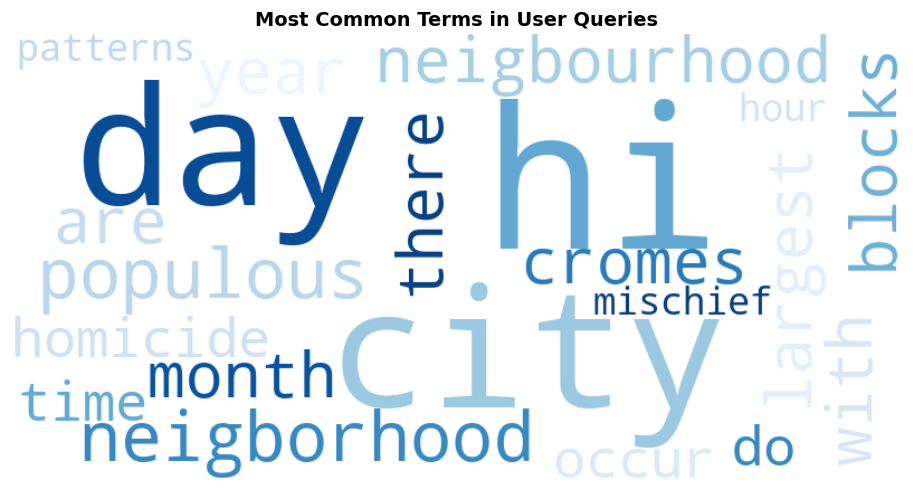

In [11]:
# Analysis of common terms in user queries using WordCloud
from wordcloud import WordCloud

text = " ".join(df["user_query"].dropna().str.lower().tolist())


extra_stopwords = {"show", "me", "the", "all", "crimes", "crime", "data",
                   "many", "how", "what", "which", "most", "has", "in", "of", "for", "by", "a", "is"}

wc = WordCloud(
    width=800,
    height=400,
    background_color="white",
    colormap="Blues",
    stopwords=extra_stopwords,
    max_words=100,
    collocations=False
)

wc.generate(text)

fig, ax = plt.subplots(figsize=(12, 5))
ax.imshow(wc, interpolation="bilinear")
ax.axis("off")
ax.set_title("Most Common Terms in User Queries", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [12]:
vancouver_neighbourhoods = ['West End', 'Sunset', 'Strathcona', 'Marpole', 'Oakridge', 'Fairview','Central Business District', 'Mount Pleasant', 'Kitsilano', 'West Point Grey', 
                            'Kensington-Cedar Cottage', 'Grandview-Woodland', 'Hastings-Sunrise', 'Arbutus Ridge', 'Kerrisdale', 'Renfrew-Collingwood', 'Killarney', 'Riley Park',
                            'Stanley Park', 'Victoria-Fraserview','Shaughnessy','Dunbar-Southlands', 'South Cambie', 'Musqueam']

neighbourhood_counts = {}
for nb in vancouver_neighbourhoods:
    count = df["sql"].str.contains(nb, case=False, na=False).sum()
    neighbourhood_counts[nb] = count

nb_series = pd.Series(neighbourhood_counts)
nb_series = nb_series[nb_series > 0].sort_values(ascending=True)
nb_df = nb_series.reset_index()
nb_df.columns = ["Neighbourhood", "Count"] 

fig = px.bar(
    nb_df,
    x="Count",
    y="Neighbourhood",
    orientation="h",
    title="Most Queried Neighbourhoods (from SQL)",
    labels={"Neighbourhood": "Neighbourhood", "Count": "Number of Queries"},
    color_discrete_sequence=["#fb8500"]
)
fig.show()

In [13]:
# Gap Analysis: Queries that returned 0 rows

empty = df[df["n_rows"] == 0]
print(f"Queries that returned 0 rows: {len(empty)} ({len(empty)/len(df)*100:.1f}%)")


Queries that returned 0 rows: 0 (0.0%)


## Data Pipeline

![Pipeline](../img/pipeline.png)
    

## Actionable Insights

1. Word cloud terms that appear often but aren't covered by the current
   dataset (e.g. "weather", "population") signal feature requests.

2. Peak usage times inform when the app should be most reliably available
   and help justify infrastructure scaling decisions.